In [1]:
%matplotlib inline 
import mne 
import numpy as np 

In [2]:
epochs = mne.read_epochs("../data/processed/sub-001_epo.fif", preload=True)
print(epochs)

Reading /Users/aidanseidman/Desktop/eeg-dementia-classifier/notebooks/../data/processed/sub-001_epo.fif ...
    Found the data of interest:
        t =       0.00 ...    3998.00 ms
        0 CTF compensation matrices available
Not setting metadata
129 matching events found
No baseline correction applied
0 projection items activated
<EpochsFIF | 129 events (all good), 0 – 3.998 s (baseline off), ~37.4 MiB, data loaded,
 '1': 129>


In [3]:
psd = epochs.compute_psd(method='welch', fmin=0.5, fmax=45.0, n_fft=1024)
print(psd)

Effective window size : 2.048 (s)
<Power Spectrum (from Epochs, welch method) | 129 epochs × 19 channels × 91 freqs, 1.0-44.9 Hz>


Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/Users/aidanseidman/Desktop/eeg-dementia-classifier/eeg_env/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


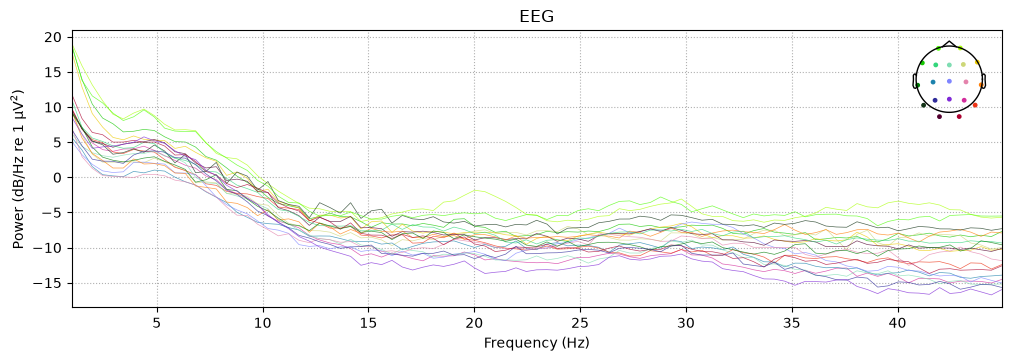

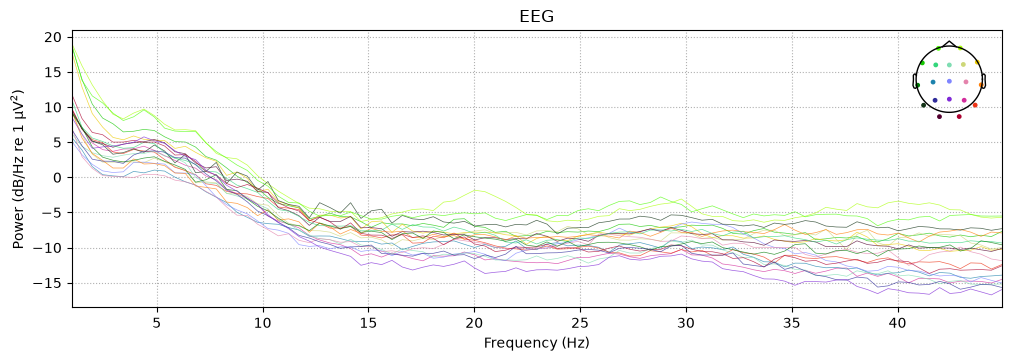

In [4]:
psd.plot()

Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/Users/aidanseidman/Desktop/eeg-dementia-classifier/eeg_env/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


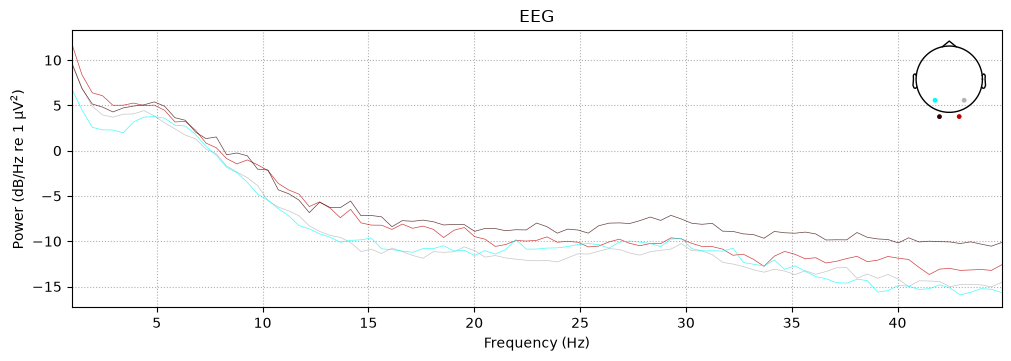

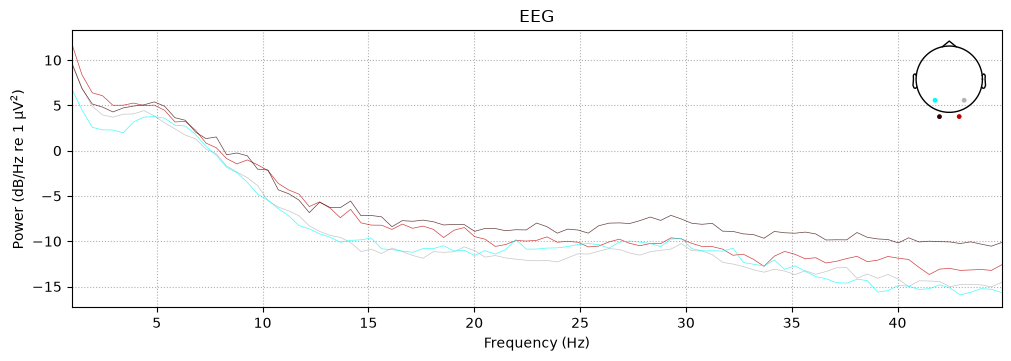

In [5]:
psd.plot(picks=['O1', 'O2', 'P3', 'P4'])

Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


/Users/aidanseidman/Desktop/eeg-dementia-classifier/eeg_env/lib/python3.12/site-packages/mne/viz/utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


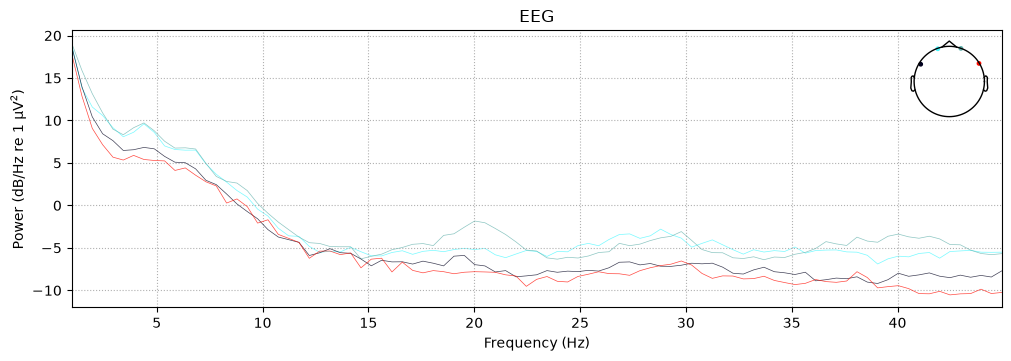

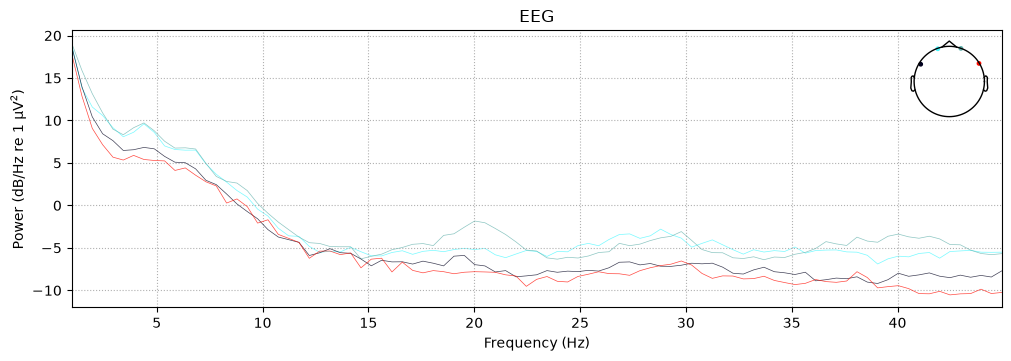

In [6]:
psd.plot(picks=['Fp1', 'Fp2', 'F7', 'F8'])

In [7]:
import importlib
from eeg_dementia import preprocessing
importlib.reload(preprocessing)
from eeg_dementia.preprocessing import preprocess_subject   # re-bind the name after reload

subjects = {
    'sub-001': 'A',   # Alzheimer's — already processed
    'sub-037': 'C',   # Control
    'sub-066': 'F',   # Frontotemporal dementia
}

results = {}
for sub_id in subjects:
    path = f"../data/raw/{sub_id}/eeg/{sub_id}_task-eyesclosed_eeg.set"
    epochs, info = preprocess_subject(path)
    results[sub_id] = {'epochs': epochs, 'info': info}
    print(f"{sub_id}: {info['n_epochs_kept']}/{info['n_epochs_total']} epochs kept, "
          f"{info['n_bad_segments']} bad segments, excluded ICA components: {info['excluded_ica_components']}")

sub-001: 129/149 epochs kept, 30 bad segments, excluded ICA components: [np.int64(0)]
sub-037: 163/194 epochs kept, 39 bad segments, excluded ICA components: [np.int64(0)]
sub-066: 114/137 epochs kept, 28 bad segments, excluded ICA components: [0]


In [8]:
epochs_066, info_066 = results['sub-066']['epochs'], results['sub-066']['info']
print(info_066['eog_correlation_scores'])

[ 0.79048121  0.43847668 -0.17443702  0.17456031 -0.13126671  0.15801488
 -0.16150341 -0.03767815  0.21303305  0.08004027  0.19584924 -0.02918599
 -0.08240292  0.09444979 -0.0272341 ]


In [9]:
scores = results['sub-066']['info']['eog_correlation_scores']
z = (scores - scores.mean()) / scores.std()
for i, (s, zi) in enumerate(zip(scores, z)):
    print(f"Component {i}: correlation={s:+.3f}  z={zi:+.2f}")

Component 0: correlation=+0.790  z=+2.81
Component 1: correlation=+0.438  z=+1.38
Component 2: correlation=-0.174  z=-1.12
Component 3: correlation=+0.175  z=+0.30
Component 4: correlation=-0.131  z=-0.94
Component 5: correlation=+0.158  z=+0.24
Component 6: correlation=-0.162  z=-1.06
Component 7: correlation=-0.038  z=-0.56
Component 8: correlation=+0.213  z=+0.46
Component 9: correlation=+0.080  z=-0.08
Component 10: correlation=+0.196  z=+0.39
Component 11: correlation=-0.029  z=-0.53
Component 12: correlation=-0.082  z=-0.74
Component 13: correlation=+0.094  z=-0.02
Component 14: correlation=-0.027  z=-0.52


In [10]:
import inspect
from eeg_dementia import preprocessing
print(inspect.getsource(preprocessing.preprocess_subject))

def preprocess_subject(
    raw_path,
    l_freq=0.5,
    h_freq=45.0,
    bad_segment_window_sec=1.0,
    bad_segment_percentile=95,
    ica_n_components=15,
    ica_random_state=42,
    eog_proxy_channel="Fp1",
    epoch_duration_sec=4.0,
    verbose=False,
):
    """
    Run the preprocessing pipeline on a single subject's raw EEG file.

    Steps: filtering -> bad channel check (informational only) -> bad segment
    annotation -> ICA eye-artifact removal -> average re-referencing -> fixed-length
    epoching with bad-segment rejection.

    Returns
    -------
    epochs : mne.Epochs
        \ epoched data ready for feature extraction.
    info : dict
        Summary diagnostics (channel z-scores, bad segment count, excluded ICA
        component, epoch counts) for sanitycheck each subject's run.
    """
    raw = mne.io.read_raw_eeglab(raw_path, preload=True, verbose=verbose)

    # Step 1: Filtering
    raw_filtered = raw.copy().filter(l_freq=l_freq, h_freq=h_freq, verbose=verbo

In [11]:
psds = {}
for sub_id, data in results.items():
    psds[sub_id] = data['epochs'].compute_psd(method='welch', fmin=0.5, fmax=45.0, n_fft=1024)

Effective window size : 2.048 (s)
Effective window size : 2.048 (s)
Effective window size : 2.048 (s)


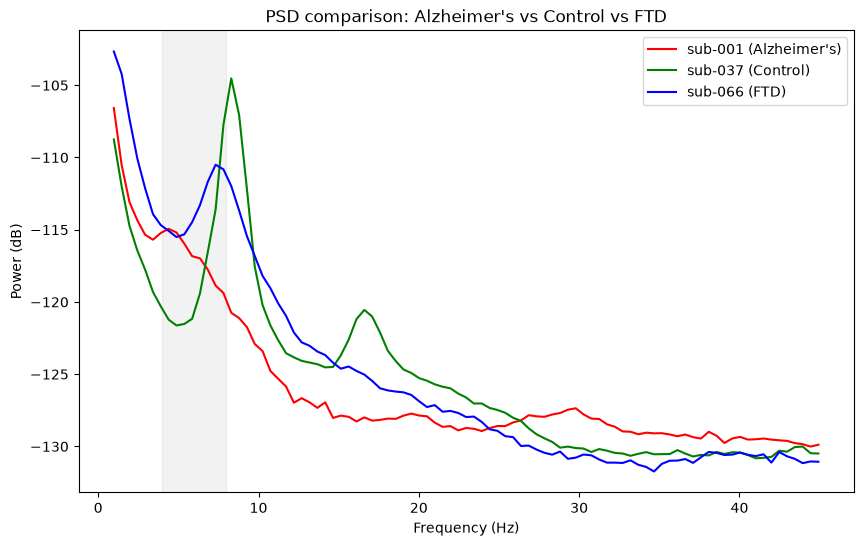

In [12]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
colors = {'sub-001': 'red', 'sub-037': 'green', 'sub-066': 'blue'}
labels = {'sub-001': 'sub-001 (Alzheimer\'s)', 'sub-037': 'sub-037 (Control)', 'sub-066': 'sub-066 (FTD)'}

for sub_id, psd in psds.items():
    mean_psd = psd.get_data().mean(axis=(0, 1))  # average across epochs and channels
    freqs = psd.freqs
    ax.plot(freqs, 10 * np.log10(mean_psd), label=labels[sub_id], color=colors[sub_id])

ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('Power (dB)')
ax.set_title('PSD comparison: Alzheimer\'s vs Control vs FTD')
ax.legend()
ax.axvspan(4, 8, alpha=0.1, color='gray', label='theta')
plt.show()

In [13]:
bands = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 12),
    'beta': (12, 30),
    'gamma': (30, 45),
}

def extract_band_power(psd):
    """
    Collapse a PSD (epochs x channels x freqs) into band power per channel,
    averaged across epochs. Returns a dict: {band_name: array of shape (n_channels,)}
    """
    data = psd.get_data()          # shape: (n_epochs, n_channels, n_freqs)
    freqs = psd.freqs

    band_power = {}
    for band_name, (fmin, fmax) in bands.items():
        freq_mask = (freqs >= fmin) & (freqs < fmax)
        power_in_band = data[:, :, freq_mask].mean(axis=2)   # (n_epochs, n_channels)
        band_power[band_name] = power_in_band.mean(axis=0)   # (n_channels,)

    return band_power

In [14]:
band_powers = {}
for sub_id, psd in psds.items():
    band_powers[sub_id] = extract_band_power(psd)

for sub_id in band_powers:
    theta = band_powers[sub_id]['theta']
    print(f"{sub_id} theta power (mean across channels): {theta.mean():.2e}")

sub-001 theta power (mean across channels): 2.12e-12
sub-037 theta power (mean across channels): 3.43e-12
sub-066 theta power (mean across channels): 5.13e-12


In [15]:
for sub_id in band_powers:
    delta = band_powers[sub_id]['delta']
    print(f"{sub_id} delta power (mean across channels): {delta.mean():.2e}")

sub-001 delta power (mean across channels): 6.86e-12
sub-037 delta power (mean across channels): 4.15e-12
sub-066 delta power (mean across channels): 1.91e-11


In [16]:
for sub_id in band_powers:
    total_power = sum(band_powers[sub_id][band].mean() for band in bands)
    print(f"\n{sub_id}:")
    for band_name in bands:
        band_val = band_powers[sub_id][band_name].mean()
        relative = band_val / total_power
        print(f"  {band_name:6s}: {relative*100:5.1f}% of total power")


sub-001:
  delta :  70.2% of total power
  theta :  21.7% of total power
  alpha :   5.3% of total power
  beta  :   1.6% of total power
  gamma :   1.2% of total power

sub-037:
  delta :  25.7% of total power
  theta :  21.2% of total power
  alpha :  50.6% of total power
  beta  :   1.9% of total power
  gamma :   0.6% of total power

sub-066:
  delta :  70.6% of total power
  theta :  19.0% of total power
  alpha :   9.3% of total power
  beta  :   0.9% of total power
  gamma :   0.3% of total power


In [17]:
def extract_relative_band_power(psd):
    """
    Compute relative (normalized) band power per channel.
    Returns a dict: {band_name: array of shape (n_channels,)}, where each value
    is that channel's power in the given band as a fraction of that channel's
    own total power across all five bands.
    """
    data = psd.get_data()          # (n_epochs, n_channels, n_freqs)
    freqs = psd.freqs

    # average across epochs first, per channel per frequency bin
    mean_psd = data.mean(axis=0)   # (n_channels, n_freqs)

    band_absolute = {}
    for band_name, (fmin, fmax) in bands.items():
        freq_mask = (freqs >= fmin) & (freqs < fmax)
        band_absolute[band_name] = mean_psd[:, freq_mask].mean(axis=1)  # (n_channels,)

    total_power_per_channel = sum(band_absolute[b] for b in bands)  # (n_channels,)

    band_relative = {
        band_name: band_absolute[band_name] / total_power_per_channel
        for band_name in bands
    }
    return band_relative

In [18]:
import pandas as pd

rows = []
for sub_id in subjects:
    rel_power = extract_relative_band_power(psds[sub_id])
    row = {'subject_id': sub_id, 'group': subjects[sub_id]}
    for band_name, values_per_channel in rel_power.items():
        for ch_name, value in zip(psds[sub_id].ch_names, values_per_channel):
            row[f"{band_name}_{ch_name}"] = value
    rows.append(row)

feature_table = pd.DataFrame(rows)
print(feature_table.shape)
feature_table.head()

(3, 97)


,subject_id,group,delta_Fp1,delta_Fp2,delta_F3,delta_F4,delta_C3,delta_C4,delta_P3,delta_P4,...,gamma_O2,gamma_F7,gamma_F8,gamma_T3,gamma_T4,gamma_T5,gamma_T6,gamma_Fz,gamma_Cz,gamma_Pz
0,sub-001,A,0.765670,0.782007,0.622752,0.607872,0.556906,0.580117,0.508472,0.638224,...,0.007257,0.006726,0.006546,0.018077,0.034314,0.030021,0.011272,0.011545,0.026412,0.005186
1,sub-037,C,0.405131,0.410533,0.291981,0.322665,0.414049,0.264039,0.081216,0.148114,...,0.002170,0.029937,0.003488,0.014629,0.010915,0.004104,0.003972,0.002777,0.003898,0.001113
2,sub-066,F,0.849698,0.862296,0.694690,0.592486,0.621914,0.557430,0.634046,0.701291,...,0.000788,0.002391,0.002473,0.026312,0.004300,0.001270,0.002214,0.000895,0.001644,0.000767


In [19]:
feature_table[['subject_id', 'group', 'theta_O1', 'alpha_O1', 'delta_O1']]

,subject_id,group,theta_O1,alpha_O1,delta_O1
0,sub-001,A,0.314331,0.083549,0.564118
1,sub-037,C,0.220772,0.615809,0.150591
2,sub-066,F,0.241598,0.116016,0.635901


In [20]:
from eeg_dementia.features import build_feature_table

subjects_epochs = {
    sub_id: (subjects[sub_id], results[sub_id]['epochs'])
    for sub_id in subjects
}

feature_table = build_feature_table(subjects_epochs)
print(feature_table.shape)
feature_table.head()

(3, 97)


,subject_id,group,delta_Fp1,delta_Fp2,delta_F3,delta_F4,delta_C3,delta_C4,delta_P3,delta_P4,...,gamma_O2,gamma_F7,gamma_F8,gamma_T3,gamma_T4,gamma_T5,gamma_T6,gamma_Fz,gamma_Cz,gamma_Pz
0,sub-001,A,0.765670,0.782007,0.622752,0.607872,0.556906,0.580117,0.508472,0.638224,...,0.007257,0.006726,0.006546,0.018077,0.034314,0.030021,0.011272,0.011545,0.026412,0.005186
1,sub-037,C,0.405131,0.410533,0.291981,0.322665,0.414049,0.264039,0.081216,0.148114,...,0.002170,0.029937,0.003488,0.014629,0.010915,0.004104,0.003972,0.002777,0.003898,0.001113
2,sub-066,F,0.849698,0.862296,0.694690,0.592486,0.621914,0.557430,0.634046,0.701291,...,0.000788,0.002391,0.002473,0.026312,0.004300,0.001270,0.002214,0.000895,0.001644,0.000767


In [21]:
import pandas as pd
features = pd.read_csv('../data/processed/features.csv')
print(features[['subject_id', 'group']])
print(features.shape)

   subject_id group
0     sub-001     A
1     sub-002     A
2     sub-003     A
3     sub-004     A
4     sub-005     A
5     sub-037     C
6     sub-038     C
7     sub-039     C
8     sub-040     C
9     sub-041     C
10    sub-066     F
11    sub-067     F
12    sub-068     F
13    sub-069     F
14    sub-070     F
(15, 97)


In [23]:
import pandas as pd

features = pd.read_csv("../data/processed/features.csv")
print(features.shape)
print(features['group'].value_counts())
print(features.isnull().sum().sum())

(88, 97)
group
A    36
C    29
F    23
Name: count, dtype: int64
0


In [24]:
from sklearn.model_selection import train_test_split

X = features.drop(columns=['subject_id', 'group'])
y = features['group']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(y_train.value_counts())
print(y_test.value_counts())

Train: (70, 95), Test: (18, 95)
group
A    29
C    23
F    18
Name: count, dtype: int64
group
A    7
C    6
F    5
Name: count, dtype: int64


In [25]:
from sklearn.ensemble import RandomForestClassifier

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train, y_train)

train_accuracy = clf.score(X_train, y_train)
test_accuracy = clf.score(X_test, y_test)

print(f"Train accuracy: {train_accuracy:.3f}")
print(f"Test accuracy: {test_accuracy:.3f}")

Train accuracy: 1.000
Test accuracy: 0.500


In [26]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(clf, X, y, cv=cv)
print(f"CV accuracy per fold: {scores}")
print(f"Mean CV accuracy: {scores.mean():.3f} (+/- {scores.std():.3f})")

CV accuracy per fold: [0.61111111 0.61111111 0.66666667 0.70588235 0.52941176]
Mean CV accuracy: 0.625 (+/- 0.060)


In [27]:
clf_constrained = RandomForestClassifier(
    n_estimators=200,
    max_depth=5,
    min_samples_leaf=3,
    random_state=42
)

scores_constrained = cross_val_score(clf_constrained, X, y, cv=cv)
print(f"Constrained CV accuracy per fold: {scores_constrained}")
print(f"Mean CV accuracy: {scores_constrained.mean():.3f} (+/- {scores_constrained.std():.3f})")

Constrained CV accuracy per fold: [0.55555556 0.66666667 0.55555556 0.70588235 0.52941176]
Mean CV accuracy: 0.603 (+/- 0.070)


In [29]:
clf.fit(X_train, y_train)  # refit on the full training set if not already current
#see if a few features feed the model, or if it is more evenly distributed, model fitting lots of noise
importances = pd.Series(clf.feature_importances_, index=X.columns)
top_20 = importances.sort_values(ascending=False).head(20)
print(top_20)

beta_T3      0.035796
delta_T5     0.026237
alpha_T5     0.025789
alpha_F7     0.024531
gamma_T3     0.022366
theta_P4     0.021878
gamma_C3     0.021192
theta_Fz     0.019564
alpha_P3     0.019156
theta_T6     0.018187
alpha_O1     0.018164
alpha_O2     0.017417
gamma_Fp2    0.017374
alpha_T3     0.017176
alpha_Fp1    0.017126
beta_Fp2     0.016268
alpha_F3     0.016185
theta_O2     0.015819
delta_O2     0.015731
theta_Pz     0.014463
dtype: float64


In [30]:
theta_alpha_cols = [c for c in X.columns if c.startswith('theta_') or c.startswith('alpha_')]
X_narrow = X[theta_alpha_cols]
print(f"Narrowed feature set: {X_narrow.shape[1]} features")

clf_narrow = RandomForestClassifier(n_estimators=200, random_state=42)
scores_narrow = cross_val_score(clf_narrow, X_narrow, y, cv=cv)
print(f"Narrowed CV accuracy per fold: {scores_narrow}")
print(f"Mean CV accuracy: {scores_narrow.mean():.3f} (+/- {scores_narrow.std():.3f})")

Narrowed feature set: 38 features
Narrowed CV accuracy per fold: [0.55555556 0.55555556 0.44444444 0.64705882 0.35294118]
Mean CV accuracy: 0.511 (+/- 0.102)


In [31]:
tad_cols = [c for c in X.columns if c.startswith(('theta_', 'alpha_', 'delta_'))]
X_tad = X[tad_cols]
print(f"Theta+alpha+delta feature set: {X_tad.shape[1]} features")

clf_tad = RandomForestClassifier(n_estimators=200, random_state=42)
scores_tad = cross_val_score(clf_tad, X_tad, y, cv=cv)
print(f"CV accuracy per fold: {scores_tad}")
print(f"Mean CV accuracy: {scores_tad.mean():.3f} (+/- {scores_tad.std():.3f})")

Theta+alpha+delta feature set: 57 features
CV accuracy per fold: [0.5        0.61111111 0.55555556 0.70588235 0.47058824]
Mean CV accuracy: 0.569 (+/- 0.084)


In [32]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, classification_report

y_pred = cross_val_predict(clf, X, y, cv=cv)

print(confusion_matrix(y, y_pred, labels=['A', 'C', 'F']))
print(classification_report(y, y_pred, labels=['A', 'C', 'F']))

[[26  8  2]
 [ 3 25  1]
 [12  7  4]]
              precision    recall  f1-score   support

           A       0.63      0.72      0.68        36
           C       0.62      0.86      0.72        29
           F       0.57      0.17      0.27        23

    accuracy                           0.62        88
   macro avg       0.61      0.59      0.56        88
weighted avg       0.61      0.62      0.58        88



In [33]:
participants = pd.read_csv("../data/raw/participants.tsv", sep="\t")

results_df = features[['subject_id', 'group']].copy()
results_df['predicted'] = y_pred
results_df = results_df.merge(
    participants[['participant_id', 'MMSE']],
    left_on='subject_id', right_on='participant_id'
)

misclassified = results_df[results_df['group'] != results_df['predicted']]
print(f"{len(misclassified)} of {len(results_df)} subjects misclassified\n")
print(misclassified[['subject_id', 'group', 'predicted', 'MMSE']].to_string(index=False))

33 of 88 subjects misclassified

subject_id group predicted  MMSE
   sub-002     A         C    22
   sub-006     A         C    14
   sub-009     A         C    23
   sub-010     A         C    20
   sub-015     A         C    18
   sub-019     A         F    14
   sub-025     A         C    20
   sub-031     A         C    22
   sub-033     A         F    20
   sub-036     A         C     9
   sub-045     C         A    30
   sub-050     C         A    30
   sub-059     C         F    30
   sub-060     C         A    30
   sub-066     F         A    20
   sub-067     F         C    24
   sub-068     F         C    25
   sub-069     F         A    22
   sub-070     F         A    22
   sub-071     F         C    20
   sub-072     F         A    18
   sub-073     F         A    22
   sub-075     F         C    22
   sub-076     F         A    24
   sub-079     F         C    18
   sub-080     F         C    20
   sub-081     F         A    18
   sub-082     F         C    27
   sub-084

In [34]:
y_binary = y.apply(lambda g: 'Dementia' if g in ['A', 'F'] else 'Control')
print(y_binary.value_counts())

clf_binary = RandomForestClassifier(n_estimators=200, random_state=42)
cv_binary = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores_binary = cross_val_score(clf_binary, X, y_binary, cv=cv_binary)
print(f"\nBinary CV accuracy per fold: {scores_binary}")
print(f"Mean CV accuracy: {scores_binary.mean():.3f} (+/- {scores_binary.std():.3f})")

group
Dementia    59
Control     29
Name: count, dtype: int64

Binary CV accuracy per fold: [0.88888889 0.66666667 0.72222222 0.88235294 0.70588235]
Mean CV accuracy: 0.773 (+/- 0.094)


In [35]:
y_pred_binary = cross_val_predict(clf_binary, X, y_binary, cv=cv_binary)
print(confusion_matrix(y_binary, y_pred_binary, labels=['Dementia', 'Control']))
print(classification_report(y_binary, y_pred_binary, labels=['Dementia', 'Control']))

[[50  9]
 [11 18]]
              precision    recall  f1-score   support

    Dementia       0.82      0.85      0.83        59
     Control       0.67      0.62      0.64        29

    accuracy                           0.77        88
   macro avg       0.74      0.73      0.74        88
weighted avg       0.77      0.77      0.77        88



In [36]:
clf_binary.fit(X, y_binary)  # fit on full data to get importances aligned with the full feature set

importances_binary = pd.Series(clf_binary.feature_importances_, index=X.columns)
top_20_binary = importances_binary.sort_values(ascending=False).head(20)
print(top_20_binary)

theta_P4     0.045056
alpha_F4     0.043141
alpha_F3     0.035203
alpha_T5     0.026848
alpha_O2     0.025080
alpha_F7     0.024318
theta_O2     0.023658
alpha_O1     0.020791
delta_T5     0.020540
theta_Pz     0.018970
theta_C4     0.018233
alpha_T6     0.017901
alpha_Fz     0.017494
theta_O1     0.017406
alpha_Fp1    0.015868
theta_T3     0.015555
theta_P3     0.015366
alpha_F8     0.015325
alpha_Cz     0.014743
alpha_Fp2    0.014489
dtype: float64
